# **Ensemble vs SubEnsemble Notebook**

#### The role of this Jupyter Notebook is to clearly compare Ensemble vs SubEnsemble Transformation. It will focus mainly on:


#### 1- Comparing and evaluating the behavior of Ensembles and SubEnsembles

#### 2- Defining 2 models with the same structure , trained respectively as Ensemble and SubEnsemble

#### 3- Predicting uncertainity

#### 4- Visualizing the uncertainity distributions using historgams

#### And also applying shared code components to ensure consistency and reduce unnecessary duplication.


#### In order to get a better grasp at their differences, and make it as simple as possible to understand, we will follow each step defined above one by one and explain. But, first of all, what is the core difference between an Ensemble and a SubEnsemble?

## **Ensemble vs SubEnsemble**



### 1. The Full Ensemble ($\mathcal{E}$)
An **ensemble** is a set of $M$ predictive models, which are combined to reduce variance and improve robustness. Its behaviour reflects contributions from *all* members, typically including both high-performing **head** models and lower-performing but diverse **tail** models.
The ensemble set $\mathcal{E}$ is defined as:
$$
\mathcal{E}=\{h_1,\ldots,h_M\}
$$
The aggregated prediction $H(x)$ is computed through an aggregation function $\mathcal{A}$:
$$
H(x)=\mathcal{A}(h_1(x),\ldots,h_M(x))
$$

### 2. The Sub-Ensemble ($\mathcal{S}$)
A **sub-ensemble** is a selected subset of the full ensemble, containing $K$ models, where $K$ is less than $M$. This subset is chosen according to a specific criterion (e.g., performance, diversity, or individual uncertainty contribution).
The sub-ensemble $\mathcal{S}$ is defined as a proper subset:
$$
\mathcal{S}\subset\mathcal{E},\quad |\mathcal{S}|=K<M
$$
The predictor $H_{\mathcal{S}}(x)$ aggregates only the selected members:
$$
H_{\mathcal{S}}(x)=\mathcal{A}\big(h_i(x)\;|\;h_i\in\mathcal{S}\big)
$$

**Key difference:**  
- An ensemble uses the *full head and tail* of models, combining accuracy and diversity.  
- A sub-ensemble uses only a *portion* of this structure (same tail/backbone, different heads), modifying the bias–variance trade-off and uncertainty behaviour.







**But why do we use both Ensemble and SubEnsemble?:**  
- Since in an Ensemble, each model is trained independently(own backbone and head), this maximizes epistemic uncertainity, but on the other hand it is too expensive to have a lot of different independent models. 

- Meanwhile a sub-ensemble use is quite cheaper. Since it uses different heads for its models, we keep the diversity source only in the heads. And the shared backbone drastically reduces training and inference cost. 

Now, lets dive into writing code.

**First step, import all the necessary libraries, load MNIST data, and set configuration parameters. For this tutorial notebook, we will be using images as data ( From MNIST ).** 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Set random seeds for reproducibility
torch.manual_seed(42)  # global seed for pytorch's random number generator
np.random.seed(42)  # global seed for numpy's random number generator

M_FULL_ENSEMBLE = 5
K_SUB_ENSEMBLE = 10
BATCH_SIZE = 64


transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ],
)


train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)


print("MNIST Dataset Information:")
print(f"  Training samples: {len(train_dataset):,}")
print(f"  Test samples: {len(test_dataset):,}")
print("  Number of classes: 10")
print("  Image shape: 28x28 (784 features when flattened)")
print(f"  Batch size: {BATCH_SIZE}")
print("\nEnsemble Configuration:")
print(f"  M_FULL_ENSEMBLE: {M_FULL_ENSEMBLE}")
print(f"  K_SUB_ENSEMBLE: {K_SUB_ENSEMBLE}")

MNIST Dataset Information:
  Training samples: 60,000
  Test samples: 10,000
  Number of classes: 10
  Image shape: 28×28 (784 features when flattened)
  Batch size: 64

Ensemble Configuration:
  M_FULL_ENSEMBLE: 5
  K_SUB_ENSEMBLE: 10


**After defining the DataLoader definitions, we should plot the MNIST images visually. We need this type of data to compare Ensemble vs SubEnsemble models, and to do so we must give both models the same input.**

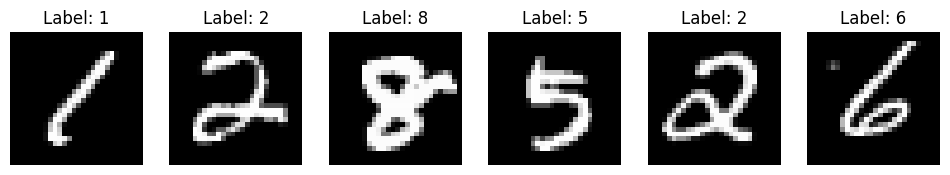

In [59]:
images, labels = next(iter(train_loader))


fig, axes = plt.subplots(1, 6, figsize=(12, 3))

for i in range(6):
    axes[i].imshow(images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")

plt.show()

**Since we are using MNIST, the data is fixed, respectively, we have train_dataset = 60,000 and test_dataset = 10,000 images. Each image has a shape of 1*28*28.**

**After generating the data we need for this notebook, we must generate a Base Model , which will be a Classification Base Model and define the parameters we need. It will act as a blueprint for both Ensemble and SubEnsemble.**

In [60]:
class BaseClassifier(nn.Module):
    """Base Classifier for MNIST classification using linear layers.

    This model serves as a blueprint for both Full Ensemble and SubEnsemble.

    Architecture:
    - Input: MNIST images of shape [batch_size, 1, 28, 28]
    - Backbone: Feature extractor (784 → H1 → H2)
      - Linear(784, H1) + ReLU
      - Linear(H1, H2) + ReLU
    - Head: Classification layer (H2 → 10 logits)
      - Linear(H2, 10)
    - Output: Logits of shape [batch_size, 10] (one for each MNIST class)

    The explicit backbone-head decomposition allows:
    - Full Ensemble: Each model has independent backbone and head
    - Sub-Ensemble: Shared backbone across all heads, independent heads only
    """

    def __init__(self, hidden_dim1: int = 512, hidden_dim2: int = 256) -> None:
        """Initialize BaseClassifier for MNIST classification.

        Args:
            hidden_dim1: Number of units in first hidden layer (H1). Default: 512
            hidden_dim2: Number of units in second hidden layer (H2). Default: 256
        """
        super().__init__()

        # Input will be flattened to 784 features inside forward_backbone
        # because flattening is a requirement for FCNN classifiers
        self.backbone = nn.Sequential(
            nn.Linear(28 * 28, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
        )

        self.head = nn.Linear(hidden_dim2, 10)

    def forward_backbone(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through backbone only (feature extraction).

        This method is used for SubEnsemble architectures
        where multiple heads share the same backbone.

        Args:
            x: Input tensor of shape [batch_size, 1, 28, 28] or [batch_size, 28, 28]

        Returns:
            z: Latent representation of shape [batch_size, hidden_dim2]
        """
        x = x.view(x.size(0), -1)
        z = self.backbone(x)
        return z

    def forward_head(self, z: torch.Tensor) -> torch.Tensor:
        """Forward pass through head only (classification).

        Takes the latent representation from the backbone and produces logits.

        Args:
            z: Latent representation of shape [batch_size, hidden_dim2]

        Returns:
            logits: Output tensor of shape [batch_size, 10]
        """
        logits = self.head(z)
        return logits

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through backbone and head.

        Since in a full ensemble each model is a complete classifier, This is the method
        needed for a Full Ensemble.

        Complete forward pass: input → backbone → head → logits.

        Args:
            x: Input tensor of shape [batch_size, 1, 28, 28] or [batch_size, 28, 28]

        Returns:
            logits: Output tensor of shape [batch_size, 10]
        """
        z = self.forward_backbone(x)
        logits = self.forward_head(z)
        return logits


def create_base_classifier(hidden_dim1: int = 512, hidden_dim2: int = 256) -> BaseClassifier:
    """Create a new BaseClassifier instance."""
    return BaseClassifier(hidden_dim1=hidden_dim1, hidden_dim2=hidden_dim2)


base_model = create_base_classifier()

# Count parameters
backbone_params = sum(p.numel() for p in base_model.backbone.parameters())
head_params = sum(p.numel() for p in base_model.head.parameters())
total_params = sum(p.numel() for p in base_model.parameters())

print("BaseClassifier Architecture:")
print("  Input: MNIST images [batch_size, 1, 28, 28]")
print("  Flattened inside model: [batch_size, 784]")
print("  Backbone: 784 → 512 → 256 (with ReLU activations)")
print("  Head: 256 → 10 (logits)")
print(f"  Backbone parameters: {backbone_params:,}")
print(f"  Head parameters: {head_params:,}")
print(f"  Total parameters: {total_params:,}")

BaseClassifier Architecture:
  Input: MNIST images [batch_size, 1, 28, 28]
  Flattened inside model: [batch_size, 784]
  Backbone: 784 → 512 → 256 (with ReLU activations)
  Head: 256 → 10 (logits)
  Backbone parameters: 533,248
  Head parameters: 2,570
  Total parameters: 535,818


**Next step, is to define the hyperparameters such as the schedular and optimizer.**

**This section prepares the training setup and trains the Full Ensemble of base learners, establishing the benchmark for the SubEnsemble comparison. 
We will now define the shared hyperparameters, for both Ensemble and SubEnsemble.**

**The next step is implementing the training loop / training Ensemble and SubEnsemble. The outer loop creates exactly M models, ensuring a sufficient large benchmark ensemble for statistical comparison. By using probly's ensemble transformation and defining a new optimizer for each model, we guarantee that each model is truly independent. We make sure that each model trains on unique data by implementing the core of Bagging (bootstrap sampling with replacement from the MNIST training dataset).** 
